In [1]:
import bilby
import numpy as np
import matplotlib.pyplot as plt
# import ringdown
from scipy.linalg import toeplitz, inv
import scipy.signal as sig
from pycbc.detector import Detector
import dill
from scipy.signal import welch
from gwpy.timeseries import TimeSeries
from gwosc.datasets import event_gps
from scipy.signal.windows import tukey
from pycbc.filter import highpass, lowpass

/opt/miniconda3/envs/LALSuite_edited/lib/python3.13/site-packages/pycbc/types/array.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal as _lal


In [10]:
import numpy as np
from scipy.linalg import circulant
from scipy.fft import fft, ifft

def inverse_circulant_first_row(c):
    eigenvalues = fft(c)
    if np.any(eigenvalues == 0):
        raise ValueError("The matrix is singular and does not have an inverse.")
    inv_eigenvalues = 1 / eigenvalues
    c_inv_first_row = ifft(inv_eigenvalues).real
    return c_inv_first_row

def acf_from_psd(psd_data,fs,N):
    delta_t = 1/fs
    rho = 0.5 * np.real(np.fft.irfft(a=psd_data,)) / (delta_t)
    return rho

In [3]:
ifos = bilby.gw.detector.get_empty_interferometer("ET")

Detectors_list = {"ET1":ifos[0],"ET2":ifos[1],"ET3":ifos[2]}

In [4]:
length_of_noise_segment = 32 # seconds
sampling_frequency = 4096  # Hz

duration = 32 # seconds of data
C_inv = {}
Noise = {}

for ifo in ifos:
    # ifo.power_spectral_density = bilby.gw.detector.PowerSpectralDensity(psd_file="ET_psd_0_freq.txt")
    ifo.set_strain_data_from_power_spectral_density(
        sampling_frequency=sampling_frequency,
        duration=duration
    )
    ifo.minimum_frequency = 0
    time_series = ifo.time_array
    noise_series = ifo.strain_data.time_domain_strain
    psd = ifo.power_spectral_density_array
    freq = ifo.frequency_array
    idx = np.where(psd==np.inf)[0]
    psd[idx] = 0
    psd[idx] = np.max(psd)
    
    ACF = acf_from_psd(psd,4096,1)
    C_inv[ifo.name] = inverse_circulant_first_row(ACF)
    Noise[ifo.name] = noise_series

Inv_cov_Noise = {"C_inv": C_inv, "Noise": Noise}
# with open("ET_C_inv_row_" + str(length_of_noise_segment) + "_sec_using_bilby_fmin_10_hz.pkl", "wb") as f:
#     dill.dump(Inv_cov_Noise, f)

In [5]:
Inv_cov_Noise

{'C_inv': {'ET1': array([ 1.88992763e+45,  8.83848661e+44,  1.39780921e+44, ...,
         -1.18202221e+44,  1.37294737e+44,  8.81968123e+44],
        shape=(131072,)),
  'ET2': array([ 1.88992763e+45,  8.83848661e+44,  1.39780921e+44, ...,
         -1.18202221e+44,  1.37294737e+44,  8.81968123e+44],
        shape=(131072,)),
  'ET3': array([ 1.88992763e+45,  8.83848661e+44,  1.39780921e+44, ...,
         -1.18202221e+44,  1.37294737e+44,  8.81968123e+44],
        shape=(131072,))},
 'Noise': {'ET1': array([8.07916451e-18, 8.08743454e-18, 8.09580806e-18, ...,
         8.05397700e-18, 8.06240922e-18, 8.07075738e-18],
        shape=(131072,)),
  'ET2': array([-4.98425051e-18, -5.01032132e-18, -5.03647186e-18, ...,
         -4.90592292e-18, -4.93201724e-18, -4.95814577e-18],
        shape=(131072,)),
  'ET3': array([-5.64695084e-18, -5.62540737e-18, -5.60376240e-18, ...,
         -5.71153038e-18, -5.68999079e-18, -5.66844223e-18],
        shape=(131072,))}}

Text(0, 0.5, 'ACF')

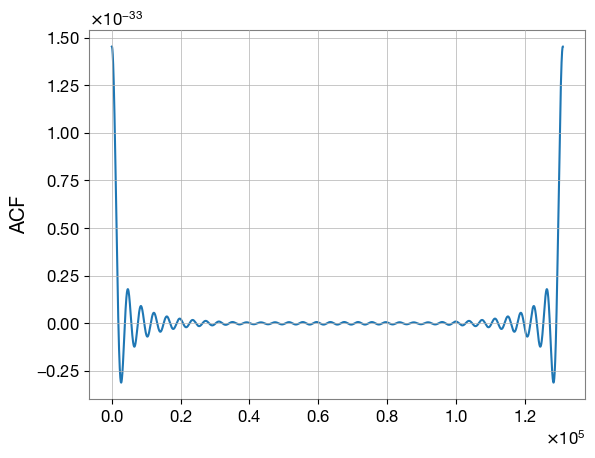

In [6]:
plt.plot(ACF)
# plt.xlabel("time (seconds)")
plt.ylabel("ACF")

## CE:

In [7]:
ifo = bilby.gw.detector.get_empty_interferometer("CE")

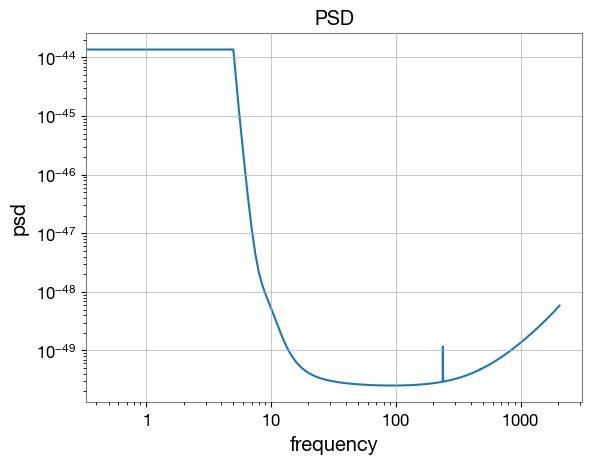

In [8]:
length_of_noise_segment = 2 # seconds
sampling_frequency = 4096  # Hz

duration = 2 # seconds of data
C_inv = {}
Noise = {}

ifo.set_strain_data_from_power_spectral_density(
    sampling_frequency=sampling_frequency,
    duration=duration
)
ifo.minimum_frequency = 0
time_series = ifo.time_array
noise_series = ifo.strain_data.time_domain_strain
psd = ifo.power_spectral_density_array
freq = ifo.frequency_array
idx = np.where(psd==np.inf)[0]
psd[idx] = 0
psd[idx] = np.max(psd)

ACF = acf_from_psd(psd,4096,1)
C_inv[ifo.name] = inverse_circulant_first_row(ACF)
Noise[ifo.name] = noise_series

# plt.loglog(freq,psd_2)
plt.loglog(freq,psd)
plt.xlabel("frequency")
plt.ylabel("psd")
plt.title("PSD")
plt.xscale("log")
plt.yscale("log")

Text(0, 0.5, 'ACF')

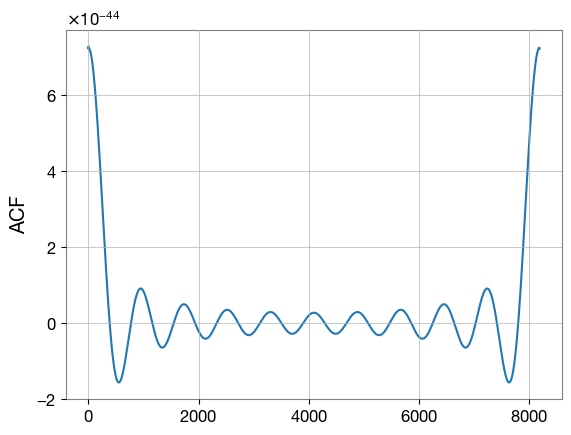

In [9]:
plt.plot(ACF)
plt.ylabel("ACF")